# Proyecto UCU

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Python para Análisis de Datos

#### Análisis de canciones de Spotify

## 1) Definición del Problema

Se cuenta con un dataset proveniente de Kaggle que se obtuvo utilizando la API de Spotify. Se tienen 114.000 registros que corresponden a _tracks_ (pistas de audio que incluyen canciones y rutinas de Stand Up), donde para cada género (_track_genre_) posible se incluyen 1000 pistas.

Nuestro objetivo será procesar el dataset y prepararlo para un eventual modelado de Machine Learning capaz de responder a la siguiente pregunta:
### **¿Es posible predecir la popularidad de una canción a partir de sus atributos?**


## Paso 2: Recopilación de datos


El dataset previamente obtenido en _import_dataset.ipynb_ se guarda como DataFrame:

In [44]:
df = pd.read_csv("../data/raw/dataset.csv")


Exploración de los campos del DataFrame:

|     Variable     | Definición                                                                                                                       | Key                                                                                                                |
|:----------------:|:---------------------------------------------------------------------------------------------------------------------------------|:-------------------------------------------------------------------------------------------------------------------|
|   Unnamed: 0   | Índice del registro                                                                                                              |                                                                                                                    |
|     track_id     | Identificador único de la canción                                                                                                |                                                                                                                    |
|     artists      | Intérprete/s                                                                                                                     |                                                                                                                    |
|    album_name    | Nombre del álbum                                                                                                                 |                                                                                                                    |
|    track_name    | Nombre de la canción                                                                                                             |                                                                                                                    |
|    popularity    | Popularidad de la canción                                                                                                        | 0 = Menor popularidad, 100 = Mayor popularidad                                                                     |
|   duration_ms    | Duración de la canción en milisegundos                                                                                           |                                                                                                                    |
|     explicit     | Indica si la canción contiene contenido explícito                                                                                | False = No, True = Sí                                                                                              |
|   danceability   | Bailabilidad (o cualidad de bailable)                                                                                            | 0 = Menos bailable, 1 = Más bailable                                                                               |
|      energy      | Medida de la intensidad de la canción                                                                                            | 0 = Baja energía, 1 = Alta energía                                                                                 |
|       key        | Tonalidad en la que está la canción                                                                                              | 0 = C, 1 = C♯/D♭, 2 = D, 3 = D♯/E♭, 4 = E, 5 = F, 6 = F♯/G♭, 7 = G, 8 = G♯/A♭, 9 = A, 10 = A♯/B♭, 11 = B |
|     loudness     | Volumen de la canción en decibeles (dB)                                                                                          | Valores relativos al máximo digital (0dB)                                                                          |
|       mode       | Indica si la tonalidad de la canción está en modo mayor o menor                                                                  | 0 = Menor, 1 = Mayor                                                                                               |
|   speechiness    | Presencia de palabras habladas en la canción                                                                                     | 0 = Poco contenido hablado, 1 = Mucho contenido hablado                                                            |
|   acousticness   | Métrica musical que mide el nivel de confianza de que la canción utilice sonidos en vivo en lugar de procesados electrónicamente | 0 = Baja probabilidad, 1 = Alta probabilidad                                                                       |
| instrumentalness | Predice si una canción no contiene voces                                                                                         | 0 = Contiene voces, 1 = Instrumental                                                                               |
|     liveness     | Probabilidad de que la grabación haya sido realizada en vivo                                                                     | 0 = Baja probabilidad, 1 = Alta probabilidad                                                                       |
|     valence      | Medida que describe la positividad musical de una canción                                                                        | 0 = Más negativa/triste, 1 = Más positiva/alegre                                                                   |
|      tempo       | Tempo estimado de la canción en pulsaciones o beats por minuto (BPM)                                                             |                                                                                                                    |
|  time_signature  | Compás estimado de la canción                                                                                                    | Va de 3 a 7, indicando compases desde 3/4 a 7/4.                                                                   |
|   track_genre    | Género musical de la canción                                                                                                     |                                                                                                                    |

El DataFrame contiene varios valores que provienen de modelos predictivos de Spotify, por lo que es posible que existan errores y es algo a tener en cuenta en el posterior análisis.

## Paso 3: Análisis Descriptivo

In [83]:
df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


* Se observa que en la columna track_name hay 89741 valores únicos en un DataFrame con 114000 registros, pero no se trata de un error. Para una misma canción el DataFrame tiene una fila por cada género de la pista.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

* 3 de las 21 columnas presentan un único dato null.
* El data type detectado para cada columna concuerda con el tipo de dato esperado en todos los casos, pero para las variables key, mode y time_signature podrían redefinirse como variables categóricas.
* La columna "Unnamed: 0" funciona como identificador.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


* Dado que una canción aparece tantas veces como la cantidad de géneros que tenga (_track_genre_), las medidas estadísticas se ven afectadas en todos los campos por la repetición de registros.
* Se detectan algunas incongruencias como los mínimos iguales a 0.000 para duration_ms y tempo.
* Se procede a identificar la cantidad de valores "0" en cada columna.

In [7]:
(df == 0).sum().sort_values(ascending=False)

explicit            104253
mode                 41319
instrumentalness     38763
popularity           16020
key                  13061
valence                176
time_signature         163
tempo                  157
danceability           157
speechiness            157
acousticness            39
liveness                 2
Unnamed: 0               1
duration_ms              1
energy                   1
artists                  0
track_id                 0
track_name               0
album_name               0
loudness                 0
track_genre              0
dtype: int64

* En algunas de estas columnas, los valores iguales a "0" están dentro de lo esperado. Por ejemplo para _mode_ que es una variable booleana, un valor de cero corresponde a una canción en tonalidad menor. Sin embargo, esto no tiene sentido para las columnas _duration_ms_, _time_signature_ o _tempo_, por lo que es algo a considerar al utilizar estos campos para relacionarlos con el resto.
* En el caso de _time_signature_, la documentación oficial de la API de Spotify establece que el rango va de 3 a 7, por lo que un valor "0" puede asignarse a que el algoritmo no logró estimar el compás: puede deberse a contenidos atípicos o a errores. Procedemos a visualizar si hay otras filas con valores fuera de ese rango para _time_signature_:

In [60]:
df["time_signature"].value_counts().sort_index()

time_signature
0       163
1       973
3      9195
4    101843
5      1826
Name: count, dtype: int64

* Existen 163 tracks con compás "0" y 973 tracks con compás "1". Continuamos analizando si corresponden predominantemente a un cierto tipo de género para ambos casos.

In [66]:
df[df["time_signature"] == 0]["track_genre"].value_counts().head(10) #Top 10 de géneros donde el time_signature es "0"

track_genre
sleep          138
guitar           4
iranian          4
ambient          3
opera            3
world-music      3
show-tunes       2
alt-rock         1
disney           1
jazz             1
Name: count, dtype: int64

In [67]:
df[df["time_signature"] == 1]["track_genre"].value_counts().head(10) #Top 10 de géneros donde el time_signature es "1"

track_genre
sleep        57
comedy       56
classical    42
ambient      39
grindcore    36
folk         30
iranian      29
opera        29
romance      29
malay        27
Name: count, dtype: int64

* En el caso de _time_signature_ = 0, el género "sleep" es el que cuenta con más registros, pero no se destaca en el caso de _time_signature_ = 1. Para simplificar estos dos casos (0 y 1) que se salen del rango esperado, más adelante se podrían combinar las categorías en una única que represente valores no detectados o atípicos.

* Continuamos buscando filas con datos nulos (que en df.info() ya habíamos visto que solo había en tres columnas):

In [8]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [9]:
df[df.isnull().any(axis=1)]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


* Los tres nulos en las columnas _artists_, _album_name_ y _track_name_ corresponden a la misma fila.
* Continuamos buscando duplicados:

In [16]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
113995    False
113996    False
113997    False
113998    False
113999    False
Length: 114000, dtype: bool

* No se encontraron duplicados. Podemos extender la búsqueda filtrando la columna track_id para evaluar si hay dos canciones con diferente track_id pero igual contenido (la misma canción con los mismos valores pero asignada a dos track_id diferentes):

In [17]:
df.duplicated(subset=df.columns.difference(['track_id'])).sum()

np.int64(0)

* Ninguna canción aparece más de una vez con diferente track_id.
* Continuamos explorando la variable _track_genre_:

In [11]:
df["track_genre"].value_counts()

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

* Tal como se mencionó en la definición del objetivo, este DataFrame contiene 114.000 registros, 114 _track_genre_ posibles y 1000 filas para cada género. Esto viene de un diseño intencional del dataset donde se buscó que cada género tuviese la misma representación, pero no podríamos estudiar la popularidad real de cada género ya que los tracks multigénero tienen un único valor de popularidad. Además, dado que tenemos exactamente la misma cantidad de registros para cada género, no podemos observar la distribución relativa de cada uno.
> Tomemos como ejemplo la canción multigénero "_I Wanna Be Yours_" de **Arctic Monkeys**:
>

In [21]:
df[(df["artists"].str.contains("Arctic Monkeys", case=False, na=False)) &
   (df["track_name"].str.contains("I Wanna Be Yours", case=False, na=False))]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
38000,38000,5XeFesFbtLpXzIVDNQP22n,Arctic Monkeys,AM,I Wanna Be Yours,92,183956,False,0.464,0.417,...,-9.345,0,0.0256,0.136,0.022,0.0974,0.479,67.528,4,garage
57003,57003,5XeFesFbtLpXzIVDNQP22n,Arctic Monkeys,AM,I Wanna Be Yours,92,183956,False,0.464,0.417,...,-9.345,0,0.0256,0.136,0.022,0.0974,0.479,67.528,4,indie
91001,91001,5XeFesFbtLpXzIVDNQP22n,Arctic Monkeys,AM,I Wanna Be Yours,92,183956,False,0.464,0.417,...,-9.345,0,0.0256,0.136,0.022,0.0974,0.479,67.528,4,rock


> Se tiene un valor relativamente alto para popularity (92), pero no podemos afirmar cuál de los tres géneros presentes ("garage", "indie" o "rock") es el que contribuye a potenciar esa variable. A partir de estas observaciones es que se decide luego eliminar _track_genre_.


* Cabe recordar que en el dataset no solamente aparecen canciones, sino que también existen registros correspondientes a rutinas de Stand Up. Por el punto anterior sabemos que hay 1000 filas del género "comedy", pero debemos establecer un criterio para separar cuáles son canciones y cuáles no. En principio se podría suponer que todos los tracks de Stand Up corresponden a rutinas en vivo, por lo que podríamos buscar aquellas filas con valores altos de _liveness_. Sin embargo, en este subconjunto entrarían shows musicales en vivo. La variable que seleccionamos para predecir con menor sesgo si un track es una rutina de Stand Up es _**Speechiness**_.
    [De la documentación oficial de la API de Spotify](https://developer.spotify.com/documentation/web-api/reference/get-audio-features):

**_Speechiness_** detecta la presencia de palabras habladas en una pista. Cuanto más exclusivamente se parezca la grabación al habla (por ejemplo, un programa de entrevistas, un audiolibro o poesía), más cercano a **1,0** será el valor del atributo.

| Valor           | Interpretación                                                                                                                   |
| --------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| **> 0,66**      | Pistas que probablemente están compuestas casi completamente por palabras habladas.                                              |
| **0,33 – 0,66** | Pistas que pueden contener tanto música como habla, ya sea en distintas secciones o superpuestas. Incluye casos como el **rap**. |
| **< 0,33**      | Pistas que probablemente corresponden a música u otros contenidos sin características similares al habla.                        |

Con esta información podemos fijar en principio un umbral de 0,66 y graficar la cantidad de filas vs _speechiness_ (dentro del género comedy):

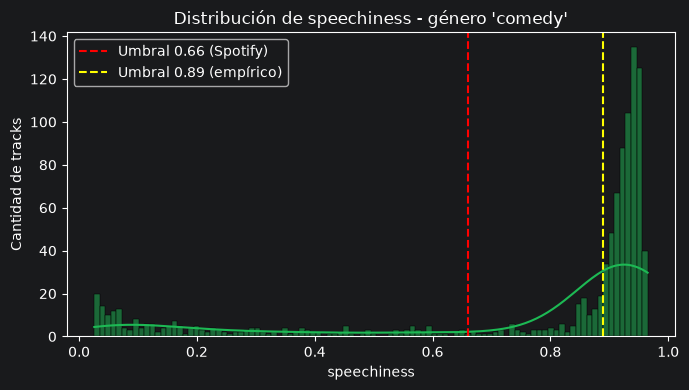

In [10]:
comedy = df[df["track_genre"] == "comedy"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(comedy["speechiness"], bins=100, kde=True, color="#1DB954", ax=ax)
ax.axvline(0.66, color="red", linestyle="--", label="Umbral 0.66 (Spotify)")
ax.axvline(0.89, color="yellow", linestyle="--", label="Umbral 0.89 (empírico)")
ax.set_title("Distribución de speechiness - género 'comedy'")
ax.set_xlabel("speechiness")
ax.set_ylabel("Cantidad de tracks")
ax.legend()
plt.tight_layout()
plt.show()

* En base al salto observado en la distribución de _speechiness_ alrededor de 0,89, se podría inferir que los tracks por encima de ese valor conforman un grupo distinto al de las canciones "comunes", probablemente correspondiente a rutinas de Stand Up (contenido mayormente hablado). Se utilizará este valor como nuevo umbral cuando limpiemos los datos.
* Antes de continuar podemos visualizar qué filas quedarán por fuera del dataset.

In [22]:
filtrado = comedy[comedy["speechiness"] > 0.89][["track_name", "album_name", "artists", "speechiness"]]
filtrado.sort_values("speechiness", ascending=True)

,track_name,album_name,artists,speechiness
18397,Afghanistan,Madigan Again,Kathleen Madigan,0.891
18435,News,Standing Up,Brian Regan,0.891
18253,Racism,As Good As Or Better Than,Simon King,0.891
18680,"Blanket, Fart, Strip",Jokes to Make My Parents Proud,Shane Mauss,0.892
18416,Inheritance,Big Underwear,Louie Anderson,0.892
...,...,...,...,...
18137,Get Rid of That Joke!,Get Outta Here; Devil!,Dan Cummins,0.962
18432,Chemotherapy,Life Since Then,Robert Schimmel,0.962
18530,Less and Less Radical,Talking for Clapping,Patton Oswalt,0.963
18504,The Real World,Human Mule,Tom Papa,0.963


* Estas 632 filas serán removidas en el Paso 4. A modo orientativo, podemos buscar los 25 artistas con más registros en este filtrado por _speechiness_ y confirmar si son comediantes o músicos.

In [16]:
comedy[comedy["speechiness"] > 0.89]["artists"].value_counts().head(25) # Top 25 de artistas dentro del filtrado

artists
Kyle Kinane                    32
Patton Oswalt                  25
Kathleen Madigan               24
Christopher Titus              18
Mike Birbiglia                 18
Tom Papa                       16
Dan Cummins                    16
Brian Regan                    14
Jeff Foxworthy                 12
Robert Schimmel                12
Larry The Cable Guy            11
Iliza Shlesinger               11
Chad Daniels                   11
Gary Gulman                    11
Ron White                      10
Big Jay Oakerson               10
Ralphie May                    10
Martin Lawrence                10
David Cross                     9
Jim Florentine;Don Jamieson     9
Katt Williams                   8
Wyatt Cenac                     8
Jeff Allen                      8
Andy Hendrickson                8
George Lopez                    8
Name: count, dtype: int64

* Los 25 artistas con más apariciones en este bloque de datos son comediantes, lo cual apunta a que el umbral definido es adecuado.

## Paso 4: Limpieza de Datos



* Primero se eliminarán las 176 filas que presentan un valor igual a 0 en al menos una de las variables _tempo_, _danceability_ o _valence_ ya que un valor "0" en alguna de estas variables puede dificultar o distorsionar la comparación entre canciones. Tratándose de un dataset con más de 100.000 registros, se considera que la eliminación de estas filas no es de impacto significativo. En otra instancia se podría haber completado los valores de _tempo_ (en caso de estar disponible como dato público), pero no los de _danceability_ o _valence_ dado que provienen de algoritmos de Spotify).
* También se eliminará la fila que contenía datos nulos por el mismo motivo.

In [36]:
df_clean = df.copy()

In [37]:
filas_cero = (
    (df_clean["tempo"] == 0) |
    (df_clean["danceability"] == 0) |
    (df_clean["valence"] == 0)
)

filas_cero.sum()

np.int64(176)

In [38]:
df_clean.drop(df_clean[filas_cero].index, inplace=True) # Se eliminan las 176 filas con valores iguales a cero incongruentes.

In [39]:
df_clean.drop(65900, axis=0, inplace=True) # Se elimina la fila con datos fantasma.

* Por lo comentado en el Paso 3, se decide eliminar la columna _track_genre_. Como alternativa se podría aplicar one-hot encoding sobre la variable _track_genre_, generando una columna booleana por cada uno de los 114 géneros presentes en el dataset. Cada fila tendría el valor 1 únicamente en la columna correspondiente a su género, y 0 en el resto.
De esta forma podríamos estudiar en profundidad las métricas de un género en particular, pero recordando que puede haber un sesgo en aquellas filas con más de un género asociado.
* Antes de realizar el filtrado de duplicados de _track_id_, otras columnas que podemos eliminar son _Unnamed: 0_, _track_name_ y _album_name_. La primera se trata de un identificador (para lo cual ya nos basta con _track_id_), y dado que las otras dos pueden estar formadas por palabras arbitrarias y ambiguas se considera que no son de gran utilidad para predecir la popularidad de una canción. Además, dado que el enfoque del trabajo es vincular _popularity_ con el resto de los atributos de una canción, también suprimiremos la columna _artists_.

In [40]:
df_clean = df_clean.drop(columns=["Unnamed: 0", "track_name", "album_name", "artists"])

* Como pasos finales, removemos los tracks con género "comedy" que tengan un _speechiness_ mayor al umbral determinado en el paso anterior, y luego borramos la columna _track_genre_. Para terminar, quitamos los duplicados de _track_id_.

In [41]:
# Eliminar registros de comedy con speechiness > 0.89
condicion_eliminar = (df_clean["track_genre"] == "comedy") & (df_clean["speechiness"] > 0.89)
df_clean = df_clean[~condicion_eliminar]

# Eliminar columna track_genre
df_clean = df_clean.drop(columns=["track_genre"])

# Eliminar duplicados por track_id
df_clean = df_clean.drop_duplicates(subset="track_id")
df_clean

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,5SuOikwiRyPMVoIQDJUgSV,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,4qPNDBW1i3p13qLCt0Ki3A,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,1iJBSr7s7jYXzM8EGcbK5b,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,6lfxq3CG4xtTiEg7opyCyx,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,5vjLSffimiIP26QG5WcN2K,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,1hIz5L4IB9hN3WRYPOCGPw,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,6x8ZfSoqDjuNa5SVP5QjvX,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,2e6sXL2bYv4bSz6VTdnfLs,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


## Paso 5: Análisis de Variables

#### Análisis de Variables Univariante Categóricas
Para este DataFrame depurado, las variables categóricas son:
* _explicit_
* _key_
* _mode_
* _time_signature_

> Pasamos a visualizar con histogramas estos campos:

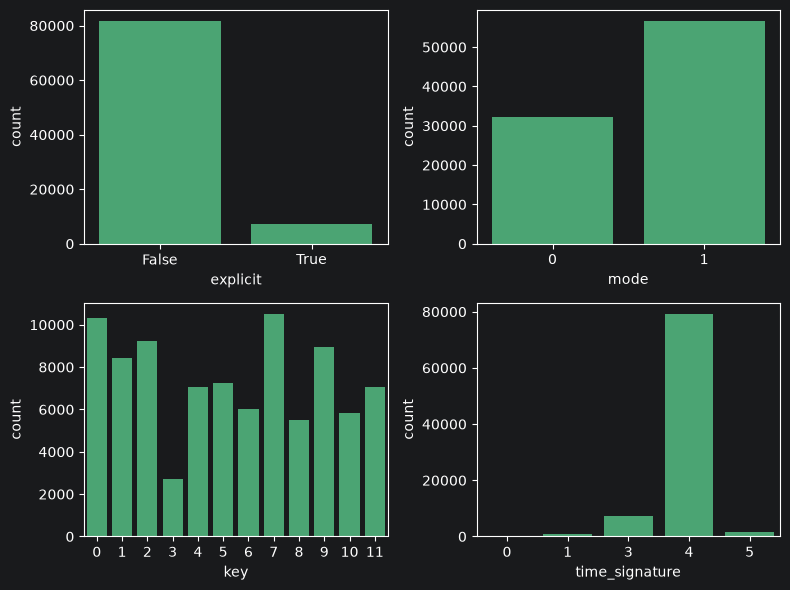

In [55]:
fig, axis = plt.subplots(2, 2, figsize=(8, 6))

sns.countplot(ax=axis[0, 0], data=df_clean, x="explicit", color="mediumseagreen")
sns.countplot(ax=axis[0, 1], data=df_clean, x="mode", color="mediumseagreen")
sns.countplot(ax=axis[1, 0], data=df_clean, x="key", color="mediumseagreen")
sns.countplot(ax=axis[1, 1], data=df_clean, x="time_signature", color="mediumseagreen")

plt.tight_layout()
plt.show()

### Observaciones
* **Explicit**: Se observa una predominancia de canciones sin contenido explícito.
* **Mode**: La cantidad de canciones en modo mayor representa casi el doble con respecto a las de modo menor.
* **Key**: Hay una clara minoría de canciones en tonalidad Re♯ (menos de 3000 registros), mientras que el recuento de aquellas en Do, Do♯, Re, Sol y La es mayor (>8000 registros) con respecto al resto.
* **Time_signature**: Hay aproximadamente 8 veces más canciones en compás 4/4 comparado con el resto de opciones. Podemos volver a visualizar también que hay registros en categorías que no se ajustan a las esperadas, tal como se comentó previamente.


#### Análisis de Variables Univariante Numéricas
Continuamos con las variables numéricas, que en nuestro caso son:
* _popularity_
* _duration_ms_
* _danceability_
* _energy_
* _loudness_
* _speechiness_
* _acousticness_
* _instrumentalness_
* _liveness_
* _valence_
* _tempo_

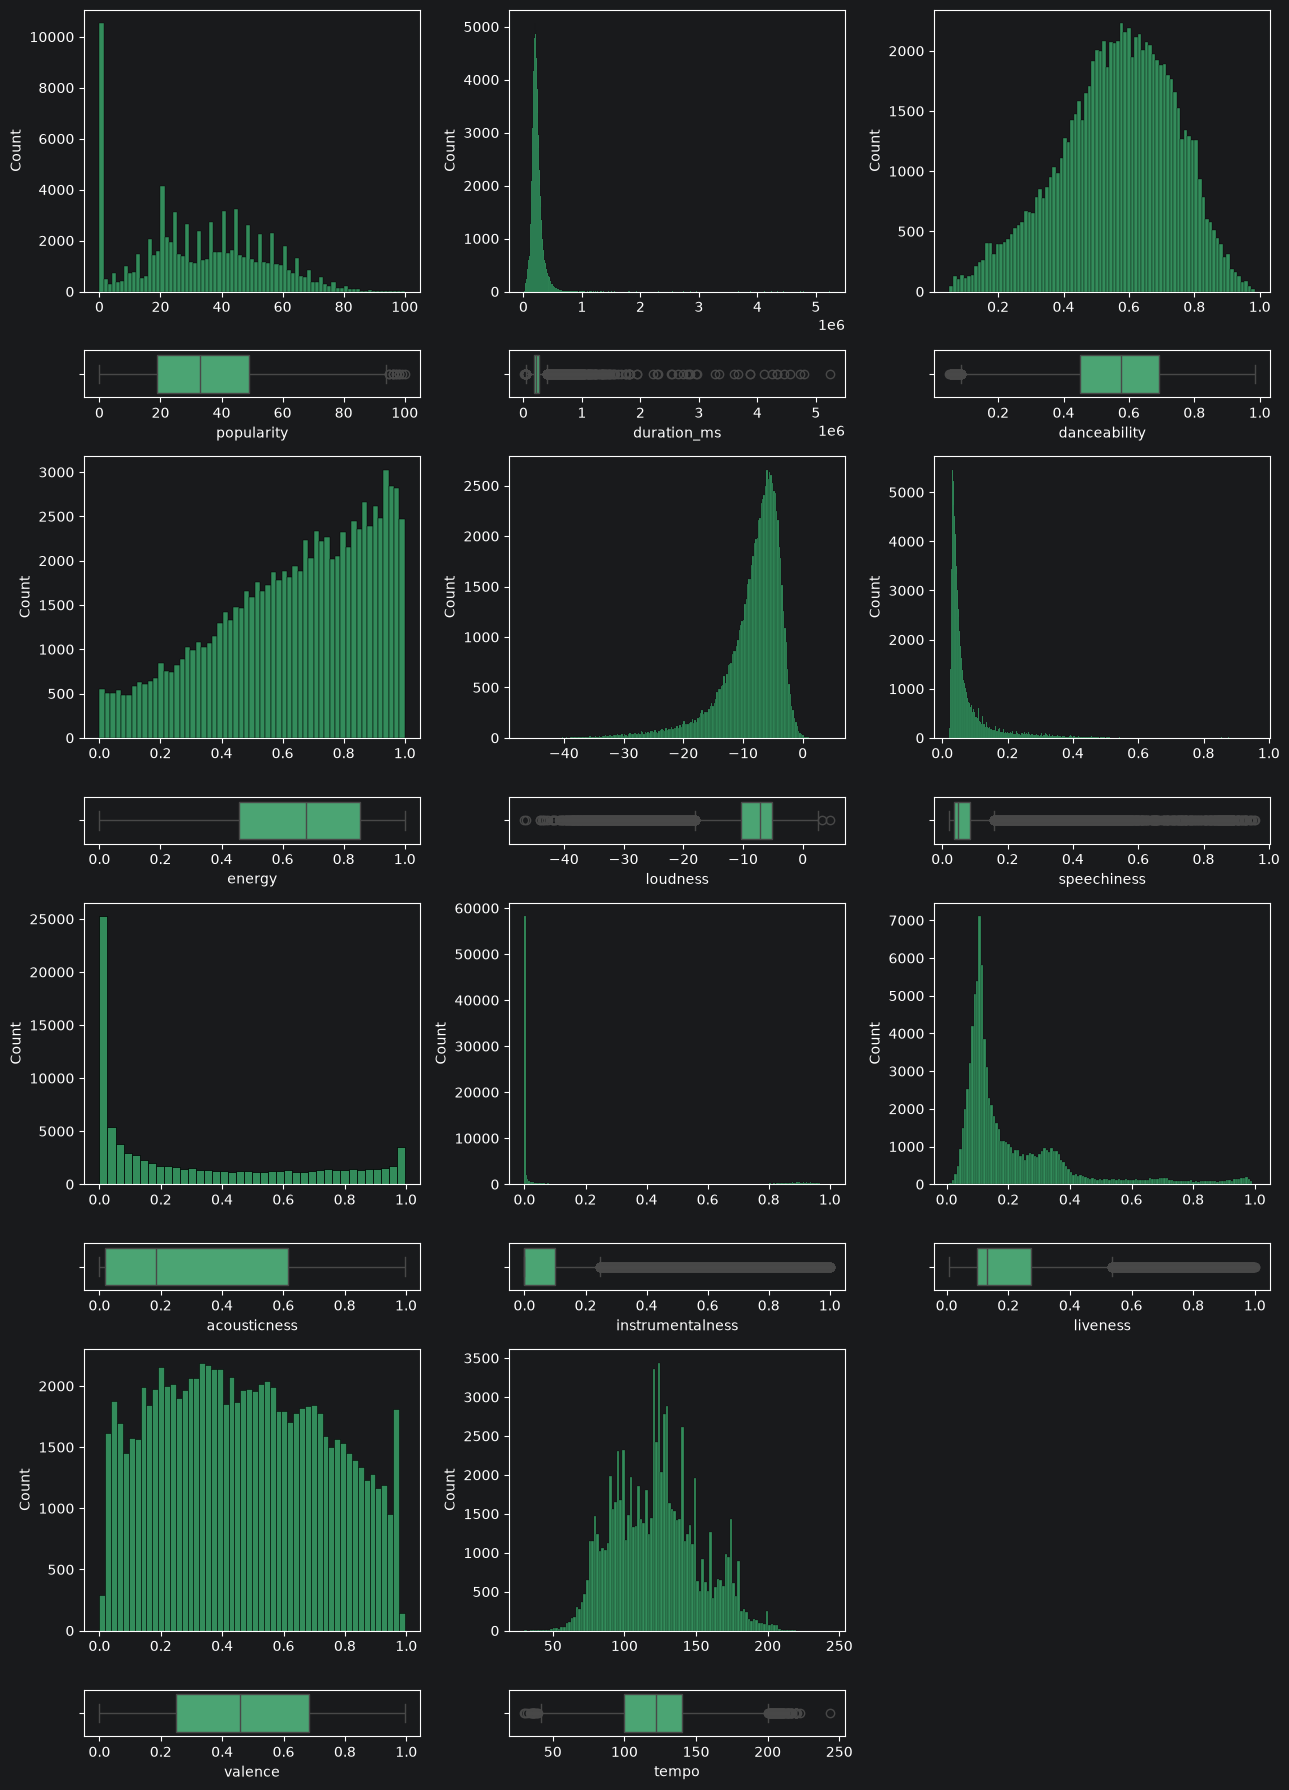

In [75]:
variables = ["popularity", "duration_ms", "danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

fig, axis = plt.subplots(8, 3, figsize=(13, 18), gridspec_kw={'height_ratios': [6, 1, 6, 1, 6, 1, 6, 1]})

sns.histplot(ax=axis[0, 0], data=df_clean, x="popularity", color="mediumseagreen").set(xlabel=None)
sns.boxplot(ax=axis[1, 0], data=df_clean, x="popularity", color="mediumseagreen")
sns.histplot(ax=axis[0, 1], data=df_clean, x="duration_ms", color="mediumseagreen").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df_clean, x="duration_ms", color="mediumseagreen")
sns.histplot(ax=axis[0, 2], data=df_clean, x="danceability", color="mediumseagreen").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df_clean, x="danceability", color="mediumseagreen")
sns.histplot(ax=axis[2, 0], data=df_clean, x="energy", color="mediumseagreen").set(xlabel=None)
sns.boxplot(ax=axis[3, 0], data=df_clean, x="energy", color="mediumseagreen")
sns.histplot(ax=axis[2, 1], data=df_clean, x="loudness", color="mediumseagreen").set(xlabel=None)
sns.boxplot(ax=axis[3, 1], data=df_clean, x="loudness", color="mediumseagreen")
sns.histplot(ax=axis[2, 2], data=df_clean, x="speechiness", color="mediumseagreen").set(xlabel=None)
sns.boxplot(ax=axis[3, 2], data=df_clean, x="speechiness", color="mediumseagreen")
sns.histplot(ax=axis[4, 0], data=df_clean, x="acousticness", color="mediumseagreen").set(xlabel=None)
sns.boxplot(ax=axis[5, 0], data=df_clean, x="acousticness", color="mediumseagreen")
sns.histplot(ax=axis[4, 1], data=df_clean, x="instrumentalness", color="mediumseagreen").set(xlabel=None)
sns.boxplot(ax=axis[5, 1], data=df_clean, x="instrumentalness", color="mediumseagreen")
sns.histplot(ax=axis[4, 2], data=df_clean, x="liveness", color="mediumseagreen").set(xlabel=None)
sns.boxplot(ax=axis[5, 2], data=df_clean, x="liveness", color="mediumseagreen")
sns.histplot(ax=axis[6, 0], data=df_clean, x="valence", color="mediumseagreen").set(xlabel=None)
sns.boxplot(ax=axis[7, 0], data=df_clean, x="valence", color="mediumseagreen")
sns.histplot(ax=axis[6, 1], data=df_clean, x="tempo", color="mediumseagreen").set(xlabel=None)
sns.boxplot(ax=axis[7, 1], data=df_clean, x="tempo", color="mediumseagreen")
axis[6, 2].axis("off")
axis[7, 2].axis("off")

plt.tight_layout()
plt.show()

### Observaciones
* **Popularity**: nuestra variable objetivo parece presentar una distribución multimodal. Además encontramos un alto recuento de tracks con popularidad = 0, lo cual puede representar tracks que no tengan tracción reciente en la plataforma (por cómo define la métrica la documentación oficial, popularity está vinculado al número de reproducciones recientes en Spotify, por lo que valores bajos puede incluir, además de canciones sin público, canciones muy viejas o canciones que acaban de lanzarse).
* **Duration_ms**: muy sesgada a la derecha con una alta concentración de canciones en un rango angosto (entre 3 y 5 minutos). Presenta muchos outliers con duraciones largas que pueden corresponder a canciones instrumentales largas, versiones extendidas o música de ambiente.
* **Danceability**: distribución bastante simétrica y con forma de campana.
* **Energy**: presenta una distribución exponencial que crece hacia la derecha.
* **Loudness**: presenta una cola larga hacia valores próximos a -40dB/-45dB, con muchos valores atípicos en esa dirección.
 * **Speechiness**: esta variable está fuertemente sesgada hacia la derecha, con un pico alto y angosto próximo a cero (la mayoría de las canciones tienen poco contenido hablado).
* **Acousticness**: Presenta una distribución no normal, con una fuerte concentración de valores próximos a 0 (canciones de producción mayoritariamente electrónica) y un incremento secundario en valores cercanos a 1 (contenido completamente acústico), dando lugar a una distribución aproximadamente en forma de U y bastante asimétrica.
* **Instrumentalness**: alta concentración de valores próximos a cero (la mayoría de tracks contienen letra). Esta variable parece no ser tan útil porque casi todos los datos tienen el mismo valor.
* **Liveness**: presenta un sesgo hacia la derecha, indicando que la mayoría de los tracks son grabaciones de estudio y no presentaciones en vivo.
* **Valence**: es la distribución más uniforme de las analizadas.
* **Tempo**: presenta una distribución unimodal, aproximadamente simétrica con un pequeño sesgo hacia la derecha. Tiene un pico cerca de los 120 BPM.
* **Duration, Speechiness e Instrumentalness**: son las variables más afectadas por los outliers.
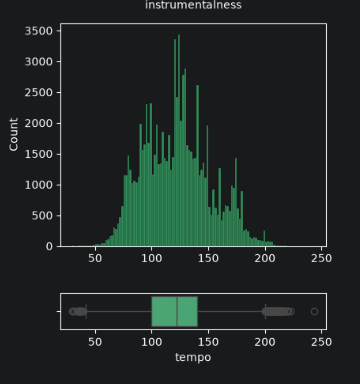

#### Análisis de variables multivariante
Antes de realizar un análisis numérico-categórico de las variables del DataFrame, buscamos si hay variables categóricas que deben ser transformadas a numéricas antes de poder utilizarlas en un heatmap:

In [85]:
df_clean["explicit"] = df_clean["explicit"].astype(int) # Solamente la variable explicit (de tipo booleana) debe ser convertida.

In [86]:
variables = ["popularity", "duration_ms", "danceability", "energy", "loudness", "speechiness","acousticness", "instrumentalness", "liveness", "valence", "tempo", "explicit", "mode", "key", "time_signature"]

correlacion = df_clean[variables].corr()

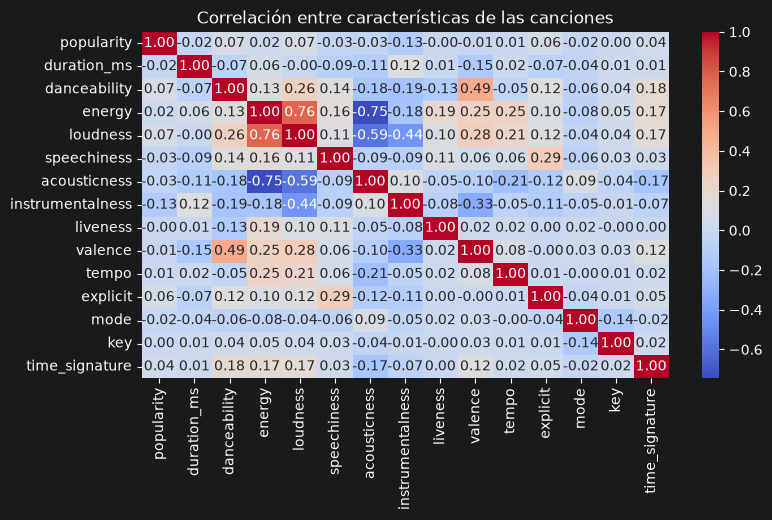

In [87]:
plt.figure(figsize=(8.5, 4.5))
mascara = np.triu(np.ones_like(correlacion, dtype=bool))
sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    mask=mascara
)

plt.title("Correlación entre características de las canciones")
plt.show()

* Se halló que las variables energy y loudness se encuentran relacionadas (0.76), lo que indicaría que las canciones con más energía tienden a tener mayor intensidad sonora.
* También se observa una relación negativa entre energy y acousticness (-0.75), por lo que se entiende que las canciones más acústicas tienen menor energía.
 * Otra relación relevante es danceability con valence (0.49), lo que sugiere que las canciones más bailables suelen ser más positivas.
  * La popularidad no muestra una dependencia significativa con ninguna de las otras variables (apenas una pequeña tendencia negativa (-0.13) con instrumentalness, indicando que el contenido "menos hablado" tiene menor tracción en la plataforma).

## Paso 6: Ingeniería de características


In [47]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,89564.0,53397.333527,33380.661382,0.00000,23726.75000,50603.500000,80478.2500,113999.000
popularity,89564.0,33.192689,20.593082,0.00000,19.00000,33.000000,49.0000,100.000
duration_ms,89564.0,229274.670537,111749.310177,17826.00000,173173.00000,213400.000000,264381.5000,5237295.000
danceability,89564.0,0.563227,0.175198,0.05130,0.45100,0.576000,0.6920,0.985
energy,89564.0,0.635468,0.255609,0.00002,0.45900,0.677000,0.8530,1.000
key,89564.0,5.283507,3.559225,0.00000,2.00000,5.000000,8.0000,11.000
loudness,89564.0,-8.472333,5.174641,-46.59100,-10.30300,-7.177000,-5.1030,4.532
mode,89564.0,0.636874,0.480903,0.00000,0.00000,1.000000,1.0000,1.000
speechiness,89564.0,0.087571,0.113304,0.02210,0.03600,0.049000,0.0860,0.965
acousticness,89564.0,0.327958,0.338081,0.00000,0.01710,0.188000,0.6240,0.996


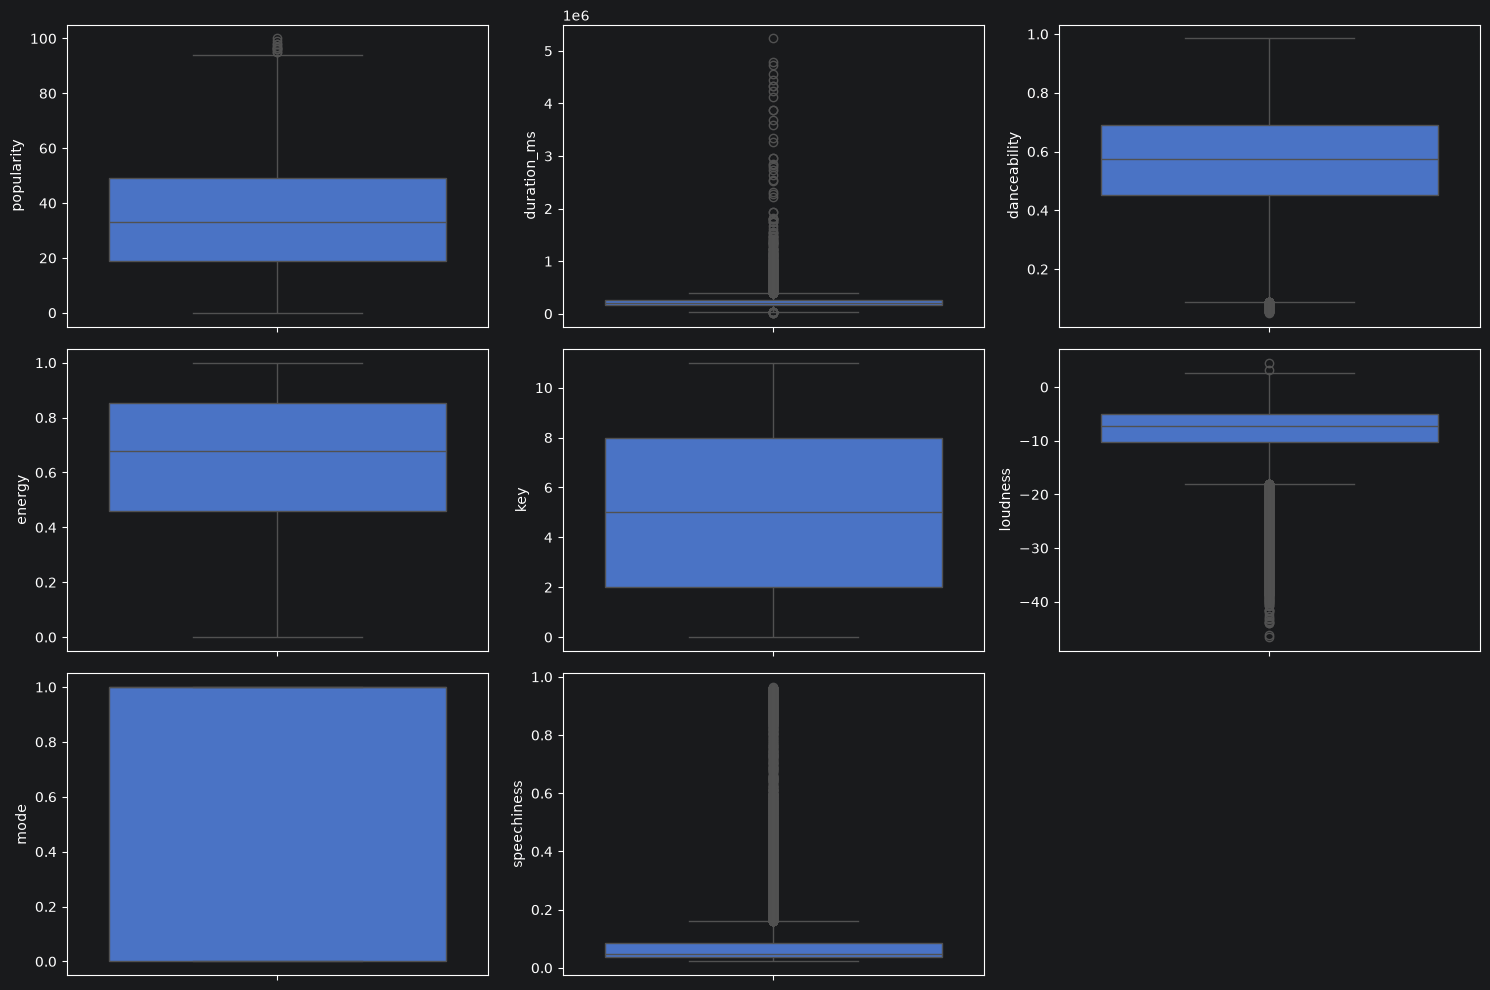

In [48]:
fig, axis = plt.subplots(3, 3, figsize=(15, 10))

sns.boxplot(ax=axis[0, 0], data=df_clean, y="popularity")
sns.boxplot(ax=axis[0, 1], data=df_clean, y="duration_ms")
sns.boxplot(ax=axis[0, 2], data=df_clean, y="danceability")
sns.boxplot(ax=axis[1, 0], data=df_clean, y="energy")
sns.boxplot(ax=axis[1, 1], data=df_clean, y="key")
sns.boxplot(ax=axis[1, 2], data=df_clean, y="loudness")
sns.boxplot(ax=axis[2, 0], data=df_clean, y="mode")
sns.boxplot(ax=axis[2, 1], data=df_clean, y="speechiness")
sns.boxplot(ax=axis[2, 2], data=df_clean, y="acousticness")
fig.delaxes(axis[2, 2])

plt.tight_layout()
plt.show()

## Observaciones

Popularity, Key, Loudness y Speechiness son las afectadas por Outliers

### Popularity

In [40]:
popularity_stats = df_clean["popularity"].describe()
popularity_stats

count    89564.000000
mean        33.192689
std         20.593082
min          0.000000
25%         19.000000
50%         33.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64

In [52]:
# Calculo el Rango inter Cuartil: IQR = Q3(75%) - Q1(25%)
q1 = df_clean["popularity"].quantile(0.25)
q3 = df_clean["popularity"].quantile(0.75)
iqr = q3 - q1

# Definir los límites inferior y superior
lower_limit = 0 if (q1 - 1.5 * iqr) < 0 else q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

f"Límites superior: {round(upper_limit, 2)}, límite inferior: {round(lower_limit, 2)}, rango intercuartílico: {round(iqr, 2)}"

'Límites superior: 94.0, límite inferior: 0, rango intercuartílico: 30.0'

In [53]:
df_clean[df_clean["popularity"] > upper_limit]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
18901,20000,5IgjP7X4th6nMNDh4akUHb,Chris Brown,Indigo (Extended),Under The Influence,96,184613,True,0.733,0.690,...,-5.529,0,0.0427,0.06350,0.000001,0.1050,0.310,116.992,4,"[dance, pop]"
18902,20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,"[dance, pop]"
18909,20008,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,"[dance, edm, pop]"
45770,51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,...,-5.548,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,[hip-hop]
57089,67356,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,"[latin, latino, reggae, reggaeton]"
57091,67358,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,True,0.911,0.712,...,-5.105,0,0.0817,0.09010,0.000027,0.0933,0.425,92.005,4,"[latin, latino, reggae, reggaeton]"
57092,67359,1IHWl5LamUGEuP4ozKQSXZ,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,97,243716,False,0.650,0.715,...,-5.198,0,0.2530,0.09930,0.000291,0.1260,0.187,106.672,4,"[latin, latino, reggae, reggaeton]"
57230,67500,3k3NWokhRRkEPhCzPmV8TW,Bad Bunny;Bomba Estéreo,Un Verano Sin Ti,Ojitos Lindos,95,258298,False,0.647,0.686,...,-5.745,0,0.0413,0.08000,0.000001,0.5280,0.268,79.928,4,"[latin, latino, reggae, reggaeton]"
57271,67559,5Eax0qFko2dh7Rl2lYs3bx,Bad Bunny,Un Verano Sin Ti,Efecto,96,213061,False,0.801,0.475,...,-8.797,0,0.0516,0.14100,0.000017,0.0639,0.234,98.047,4,"[latin, latino, reggae, reggaeton]"
65987,79000,4h9wh7iOZ0GGn8QVp4RAOB,OneRepublic,I Ain’t Worried (Music From The Motion Picture...,I Ain't Worried,96,148485,False,0.704,0.797,...,-5.927,1,0.0475,0.08260,0.000745,0.0546,0.825,139.994,4,"[piano, pop, rock]"


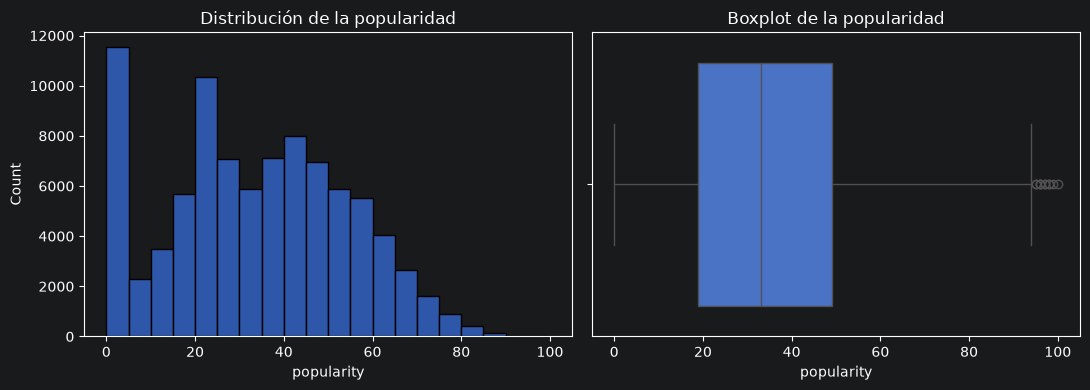

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(
    data=df_clean,
    x="popularity",
    bins=20,
    ax=axes[0]
)
axes[0].set_title("Distribución de la popularidad")

sns.boxplot(
    data=df_clean,
    x="popularity",
    ax=axes[1]
)
axes[1].set_title("Boxplot de la popularidad")

plt.tight_layout()
plt.show()

#### Conclusiones

La variable popularidad, se encuentra definida en una escala de 0 a 100. El método del rango intercuartílico puede señalar las canciones con popularidad 100 como valores atípicos debido a que son poco frecuentes dentro de la distribución. Sin embargo, estos valores respetan el dominio de la variable y representan observaciones posibles, por lo que se decide conservarlos. También se mantienen los valores iguales a 0, ya que representan canciones con mínima popularidad y no datos faltantes.

### Loudness

loudness representa la intensidad sonora promedio de una canción, medida en decibeles.

valores cercanos a 0 representan canciones más intensas;
valores muy negativos representan canciones más silenciosas;

In [55]:
loudness_stats = df_clean["loudness"].describe()
loudness_stats

count    89564.000000
mean        -8.472333
std          5.174641
min        -46.591000
25%        -10.303000
50%         -7.177000
75%         -5.103000
max          4.532000
Name: loudness, dtype: float64

In [57]:
# Calculo el Rango inter Cuartil: IQR = Q3(75%) - Q1(25%)
q1 = df_clean["loudness"].quantile(0.25)
q3 = df_clean["loudness"].quantile(0.75)
iqr = q3 - q1

# Definir los límites inferior y superior
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

f"Límites superior: {round(upper_limit, 2)}, límite inferior: {round(lower_limit, 2)}, rango intercuartílico: {round(iqr, 2)}"

'Límites superior: 2.7, límite inferior: -18.1, rango intercuartílico: 5.2'

In [58]:
loudness_outliers = df_clean[
    (df_clean["loudness"] < lower_limit) |
    (df_clean["loudness"] > upper_limit)
]

cantidad = loudness_outliers.shape[0]
porcentaje = cantidad / df_clean.shape[0] * 100

print(f"Cantidad de outliers: {cantidad}")
print(f"Porcentaje de outliers: {porcentaje:.2f}%")

Cantidad de outliers: 4927
Porcentaje de outliers: 5.50%


In [62]:
outliers_inferiores = df_clean[
    df_clean["loudness"] < lower_limit
]

outliers_superiores = df_clean[
    df_clean["loudness"] > upper_limit
]

print(f"Outliers inferiores: {len(outliers_inferiores)}")
print(f"Outliers superiores: {len(outliers_superiores)}")

outliers_inferiores[
    ["track_name", "artists", "loudness", "track_genre"]
].sort_values("loudness").head(10)




Outliers inferiores: 4925
Outliers superiores: 2


,track_name,artists,loudness,track_genre
80526,Ceiling Fan Sound on Low Power,Atmosphere Asmr,-46.591,[sleep]
80235,Cricket Sound 4 - Loopable With No Fade,White Noise for Babies;Crickets;Baby Sleep Sounds,-46.251,[sleep]
66548,Chaconne in sol maggiore : Variazione 9,Lazar Berman,-43.957,[piano]
80739,Nap in the Afternoon Box Fan,Binaural Beats;White Noise Babies;Binaural Bea...,-43.943,[sleep]
80736,Loopable Woods,Relaxing Music Therapy;4D Nature Recordings;Cr...,-43.714,[sleep]
80326,Sleep Sound For Babies - Underwater,Wave Sounds For Sleep,-43.504,[sleep]
66446,Wake with me,Brian Lyndon,-43.303,[piano]
89093,Sonidos de Aves,Sonidos De Aves,-43.043,[world-music]
80345,"White Noise - Hi Res 178,9 hz",Granular,-42.631,[sleep]
35654,Message from Home,Hans Zimmer,-42.044,[german]


In [63]:
outliers_superiores[
    ["track_name", "artists", "loudness", "track_genre"]
].sort_values("loudness", ascending=False).head(10)

,track_name,artists,loudness,track_genre
16544,Fate Dance,Five Star Hotel,4.532,[club]
50735,Islamic Capitalism,Najand,3.156,[iranian]


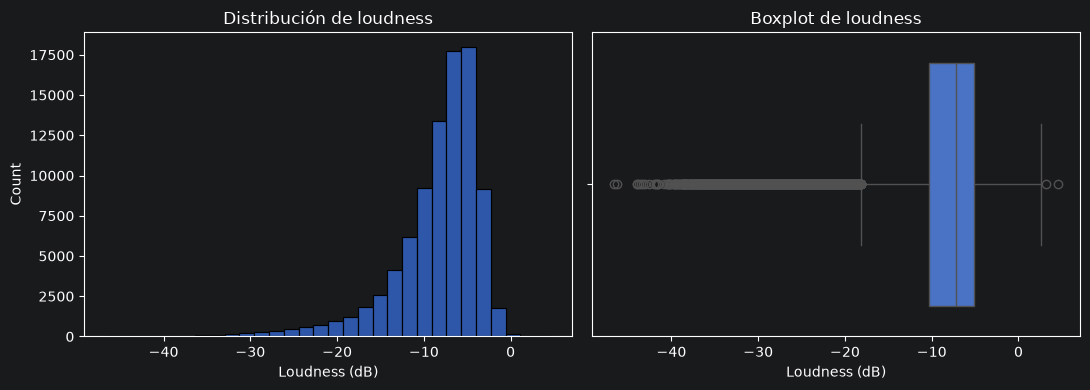

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(
    data=df_clean,
    x="loudness",
    bins=30,
    ax=axes[0]
)
axes[0].set_title("Distribución de loudness")
axes[0].set_xlabel("Loudness (dB)")

sns.boxplot(
    data=df_clean,
    x="loudness",
    ax=axes[1]
)
axes[1].set_title("Boxplot de loudness")
axes[1].set_xlabel("Loudness (dB)")

plt.tight_layout()
plt.show()

In [54]:
df_clean[df_clean["loudness"] > 2]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
16544,17574,0HfHtjS9S9q4DGVC3uIIRB,Five Star Hotel,Gray Data,Fate Dance,16,237000,False,0.310,0.999,...,4.532,0,0.3430,0.000102,0.945000,0.148,0.0333,160.040,4,[club]
34989,38840,7K0pkS5lqUkFd9kuY0spiK,The Red Pears,We Bring Anything to the Table... Except Table...,Time Bomb,25,176065,False,0.442,0.800,...,2.574,1,0.0686,0.262000,0.000001,0.664,0.3690,118.053,4,[garage]
50735,59225,5rm5Zqktf6v3u9yGj6RR5W,Najand,In the Night of Revolution,Islamic Capitalism,0,60056,False,0.149,0.868,...,3.156,0,0.0767,0.191000,0.865000,0.625,0.0494,136.188,3,[iranian]


#### Conclusiones

Se identificaron 4.927 registros potencialmente atipicos lo cual equivale a 5,5% del dataset, debido a que representa una porcion relevante, su eliminacion podria alterar la representacion de determinados generos musicales.
ademas esto no implica que el valor sea incorrecto.

### Speechiness

Esta variable mide a presencia de palabras habladas en una canción.
Cuanto mas alto el valor mayor es la presencia de contenido hablado en la cancion.


In [64]:
speechiness_stats = df_clean["speechiness"].describe()
speechiness_stats

count    89564.000000
mean         0.087571
std          0.113304
min          0.022100
25%          0.036000
50%          0.049000
75%          0.086000
max          0.965000
Name: speechiness, dtype: float64

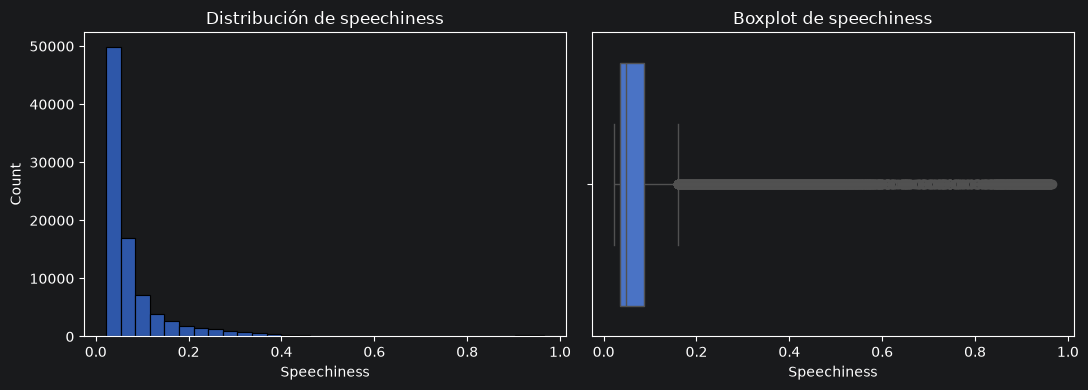

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(
    data=df_clean,
    x="speechiness",
    bins=30,
    ax=axes[0]
)
axes[0].set_title("Distribución de speechiness")
axes[0].set_xlabel("Speechiness")

sns.boxplot(
    data=df_clean,
    x="speechiness",
    ax=axes[1]
)
axes[1].set_title("Boxplot de speechiness")
axes[1].set_xlabel("Speechiness")

plt.tight_layout()
plt.show()

In [73]:
q1 = df_clean["speechiness"].quantile(0.25)
q3 = df_clean["speechiness"].quantile(0.75)
iqr = q3 - q1

statistical_lower_limit = q1 - 1.5 * iqr
statistical_upper_limit = q3 + 1.5 * iqr

lower_limit = max(0, statistical_lower_limit)
upper_limit = min(1, statistical_upper_limit)

f"Límites superior: {round(upper_limit, 4)}, límite inferior: {round(lower_limit, 4)}, rango intercuartílico: {round(iqr, 4)}"


'Límites superior: 0.161, límite inferior: 0, rango intercuartílico: 0.05'

In [77]:
speechiness_outliers = df_clean[
    (df_clean["speechiness"] < lower_limit) |
    (df_clean["speechiness"] > upper_limit)
]

cantidad = speechiness_outliers.shape[0]
porcentaje = cantidad / df_clean.shape[0] * 100

f"Cantidad de outliers: {cantidad},Porcentaje de outliers: {porcentaje:.2f} %"

'Cantidad de outliers: 10635,Porcentaje de outliers: 11.87 %'

In [80]:
df_clean.explode("track_genre").groupby(
    "track_genre"
)["speechiness"].median().sort_values(ascending=False).head(15)

track_genre
comedy         0.91700
j-dance        0.22000
dancehall      0.15600
grindcore      0.12300
hardcore       0.10600
death-metal    0.09530
hip-hop        0.09480
kids           0.09350
metalcore      0.09190
reggaeton      0.08710
latino         0.08600
happy          0.08280
hardstyle      0.08270
sad            0.08165
reggae         0.08130
Name: speechiness, dtype: float64

#### Conclusion

Se ientificarion como outliers  un 11.87 % de las canciones, sin embargo se encuentran entre el rango valido de valores.
analizando el genero de estas canciones se encuentra qeu la mayoria corresponde al genero Comedy, por este motivo se considera que representan caracteristicas reales del genero y no son errores en los datos.

debido a esto se mantiene en el dataset.

## Paso 7: Split (dos métodos o enfoques)

## Paso 8: Scaling & Encoding

### Guardamos el DS Procesado

In [83]:
os.makedirs("../data/processed", exist_ok=True)
df_clean.to_csv("../data/processed/spotify_processed.csv", index=False)

## Paso 9: Selección de características

# Resumen